In [1]:
import os
import gc
import yaml
import shutil
import kagglehub
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print(tf.__version__)

2.20.0


In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "yusufmurtaza01/tomato-leaf-disease"
)

print(dataset_path)

100%|██████████| 445M/445M [00:05<00:00, 80.4MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2


In [3]:
#find YAML
for root, dirs, files in os.walk(dataset_path):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")
        print(yaml_path)

/root/.cache/kagglehub/datasets/yusufmurtaza01/tomato-leaf-disease/versions/2/tomato/data.yaml


In [4]:
#cell-4: load classes
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

NUM_CLASSES = len(class_names)

print(NUM_CLASSES)

for idx, cls in enumerate(class_names):
    print(idx, "->", cls)

10
0 -> Tomato__BacterialSpot
1 -> Tomato__EarlyBlight
2 -> Tomato__Healthy
3 -> Tomato__LateBlight
4 -> Tomato__LeafMold
5 -> Tomato__MosaicVirus
6 -> Tomato__SeptoriaLeafSpot
7 -> Tomato__SpiderMites
8 -> Tomato__TargetSpot
9 -> Tomato__YellowLeafCurlVirus


In [5]:
#create classification datASET
ROOT = "/kaggle/working/tomato_classification"

os.makedirs(ROOT, exist_ok=True)

os.makedirs(ROOT + "/train", exist_ok=True)
os.makedirs(ROOT + "/val", exist_ok=True)

print(ROOT)

/kaggle/working/tomato_classification


CELL 6 was the YOLO → classification folder conversion step.

In [6]:
from PIL import Image

IMG_TRAIN = os.path.join(
    os.path.dirname(yaml_path),
    "images/train"
)

IMG_VAL = os.path.join(
    os.path.dirname(yaml_path),
    "images/val"
)

LBL_TRAIN = os.path.join(
    os.path.dirname(yaml_path),
    "labels/train"
)

LBL_VAL = os.path.join(
    os.path.dirname(yaml_path),
    "labels/val"
)

# Create class folders
for cls in class_names:
    os.makedirs(
        os.path.join(ROOT, "train", cls),
        exist_ok=True
    )
    os.makedirs(
        os.path.join(ROOT, "val", cls),
        exist_ok=True
    )

# TRAIN
count_train = 0

for label_file in tqdm(os.listdir(LBL_TRAIN)):

    if not label_file.endswith(".txt"):
        continue

    with open(
        os.path.join(LBL_TRAIN, label_file),
        "r"
    ) as f:

        cls_id = int(
            f.readline().split()[0]
        )

    cls_name = class_names[cls_id]

    img_name = label_file.replace(
        ".txt",
        ".jpg"
    )

    src_img = os.path.join(
        IMG_TRAIN,
        img_name
    )

    dst_img = os.path.join(
        ROOT,
        "train",
        cls_name,
        img_name
    )

    if os.path.exists(src_img):
        shutil.copy(src_img, dst_img)
        count_train += 1

print("train copied:", count_train)

# VALIDATION
count_val = 0

for label_file in tqdm(os.listdir(LBL_VAL)):

    if not label_file.endswith(".txt"):
        continue

    with open(
        os.path.join(LBL_VAL, label_file),
        "r"
    ) as f:

        cls_id = int(
            f.readline().split()[0]
        )

    cls_name = class_names[cls_id]

    img_name = label_file.replace(
        ".txt",
        ".jpg"
    )

    src_img = os.path.join(
        IMG_VAL,
        img_name
    )

    dst_img = os.path.join(
        ROOT,
        "val",
        cls_name,
        img_name
    )

    if os.path.exists(src_img):
        shutil.copy(src_img, dst_img)
        count_val += 1

print("val copied:", count_val)

print("CONVERSION COMPLETE")

100%|██████████| 12168/12168 [00:05<00:00, 2173.15it/s]


train copied: 12168


100%|██████████| 3041/3041 [00:01<00:00, 2961.72it/s]

val copied: 3041
CONVERSION COMPLETE


In [7]:
#Load Dataset
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    ROOT + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    ROOT + "/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

class_names = train_ds.class_names

print(class_names)

Found 12168 files belonging to 10 classes.
Found 3041 files belonging to 10 classes.
['Tomato__BacterialSpot', 'Tomato__EarlyBlight', 'Tomato__Healthy', 'Tomato__LateBlight', 'Tomato__LeafMold', 'Tomato__MosaicVirus', 'Tomato__SeptoriaLeafSpot', 'Tomato__SpiderMites', 'Tomato__TargetSpot', 'Tomato__YellowLeafCurlVirus']


In [8]:
#optimize
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

print("Dataset Optimized")

Dataset Optimized


In [9]:
#augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

print("Augmentation Ready")

Augmentation Ready


Channel Attention

In [10]:
def channel_attention(inputs, ratio=8):

    channels = inputs.shape[-1]

    avg_pool = tf.keras.layers.GlobalAveragePooling2D()(inputs)

    dense1 = tf.keras.layers.Dense(
        channels // ratio,
        activation="relu"
    )(avg_pool)

    dense2 = tf.keras.layers.Dense(
        channels,
        activation="sigmoid"
    )(dense1)

    attention = tf.keras.layers.Reshape(
        (1,1,channels)
    )(dense2)

    return tf.keras.layers.Multiply()(
        [inputs, attention]
    )

Spatial Attention

In [11]:
def spatial_attention(inputs):

    avg_pool = tf.keras.layers.Lambda(
        lambda x: tf.reduce_mean(
            x,
            axis=-1,
            keepdims=True
        ),
        output_shape=lambda s: (s[0], s[1], s[2], 1)
    )(inputs)

    max_pool = tf.keras.layers.Lambda(
        lambda x: tf.reduce_max(
            x,
            axis=-1,
            keepdims=True
        ),
        output_shape=lambda s: (s[0], s[1], s[2], 1)
    )(inputs)

    concat = tf.keras.layers.Concatenate(
        axis=-1
    )([avg_pool, max_pool])

    attention = tf.keras.layers.Conv2D(
        1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(concat)

    return tf.keras.layers.Multiply()(
        [inputs, attention]
    )

CBAM Block

In [12]:
def cbam_block(inputs):

    x = channel_attention(inputs)

    x = spatial_attention(x)

    return x

In [13]:
base_model_cbam = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model_cbam.trainable = False

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
#build CBAM
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model_cbam(
    x,
    training=False
)

x = cbam_block(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

cbam_model = tf.keras.Model(
    inputs,
    outputs
)

cbam_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ sequential[0][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 120)       │    115,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 960)       │    116,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 960) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_8          │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 7, 7, 1)   │          0 │ multiply_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 2)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 7, 7, 960) │          0 │ multiply_8[0][0], │
│ (Multiply)          │                   │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_9[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 960)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │      9,610 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,237,541 (12.35 MB)

 Trainable params: 241,189 (942.14 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [15]:
cbam_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_cbam_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

csv_logger = tf.keras.callbacks.CSVLogger(
    "/kaggle/working/cbam_training_log.csv"
)

In [17]:
cbam_history = cbam_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        checkpoint,
        early_stop,
        csv_logger
    ]
)

Epoch 1/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6042 - loss: 1.2388
Epoch 1: val_accuracy improved from None to 0.85235, saving model to /kaggle/working/best_cbam_model.keras

Epoch 1: finished saving model to /kaggle/working/best_cbam_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 662s 2s/step - accuracy: 0.7386 - loss: 0.8300 - val_accuracy: 0.8524 - val_loss: 0.4713
Epoch 2/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8757 - loss: 0.4063
Epoch 2: val_accuracy improved from 0.85235 to 0.87537, saving model to /kaggle/working/best_cbam_model.keras

Epoch 2: finished saving model to /kaggle/working/best_cbam_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 646s 2s/step - accuracy: 0.8814 - loss: 0.3786 - val_accuracy: 0.8754 - val_loss: 0.3780
Epoch 3/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9056 - loss: 0.2989
Epoch 3: val_accuracy did not improve from 0.87537
381/381 ━━━━━━━━━━━━━━━━━━━━ 592s 2s/step - accuracy: 0.9074 - loss: 0.2864 - val_accuracy: 0.8

In [18]:
print(max(cbam_history.history["accuracy"]))
print(max(cbam_history.history["val_accuracy"]))

0.9738658666610718
0.9289707541465759


In [19]:
cbam_model.save(
    "/kaggle/working/cbam_model.keras"
)

In [20]:
#evaluation
y_true = np.concatenate(
    [y.numpy() for x, y in val_ds]
)

cbam_probs = cbam_model.predict(val_ds)

cbam_pred = np.argmax(
    cbam_probs,
    axis=1
)

96/96 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step


In [21]:
#classification report
print(
    classification_report(
        y_true,
        cbam_pred,
        target_names=class_names
    )
)

                             precision    recall  f1-score   support

      Tomato__BacterialSpot       0.95      0.92      0.93       400
        Tomato__EarlyBlight       0.91      0.83      0.87       218
            Tomato__Healthy       0.96      0.98      0.97       332
         Tomato__LateBlight       0.93      0.97      0.95       400
           Tomato__LeafMold       0.94      0.89      0.92       208
        Tomato__MosaicVirus       0.98      0.71      0.82        85
   Tomato__SeptoriaLeafSpot       0.85      0.95      0.90       383
        Tomato__SpiderMites       0.92      0.94      0.93       335
         Tomato__TargetSpot       0.89      0.93      0.91       280
Tomato__YellowLeafCurlVirus       0.99      0.95      0.97       400

                   accuracy                           0.93      3041
                  macro avg       0.93      0.91      0.92      3041
               weighted avg       0.93      0.93      0.93      3041



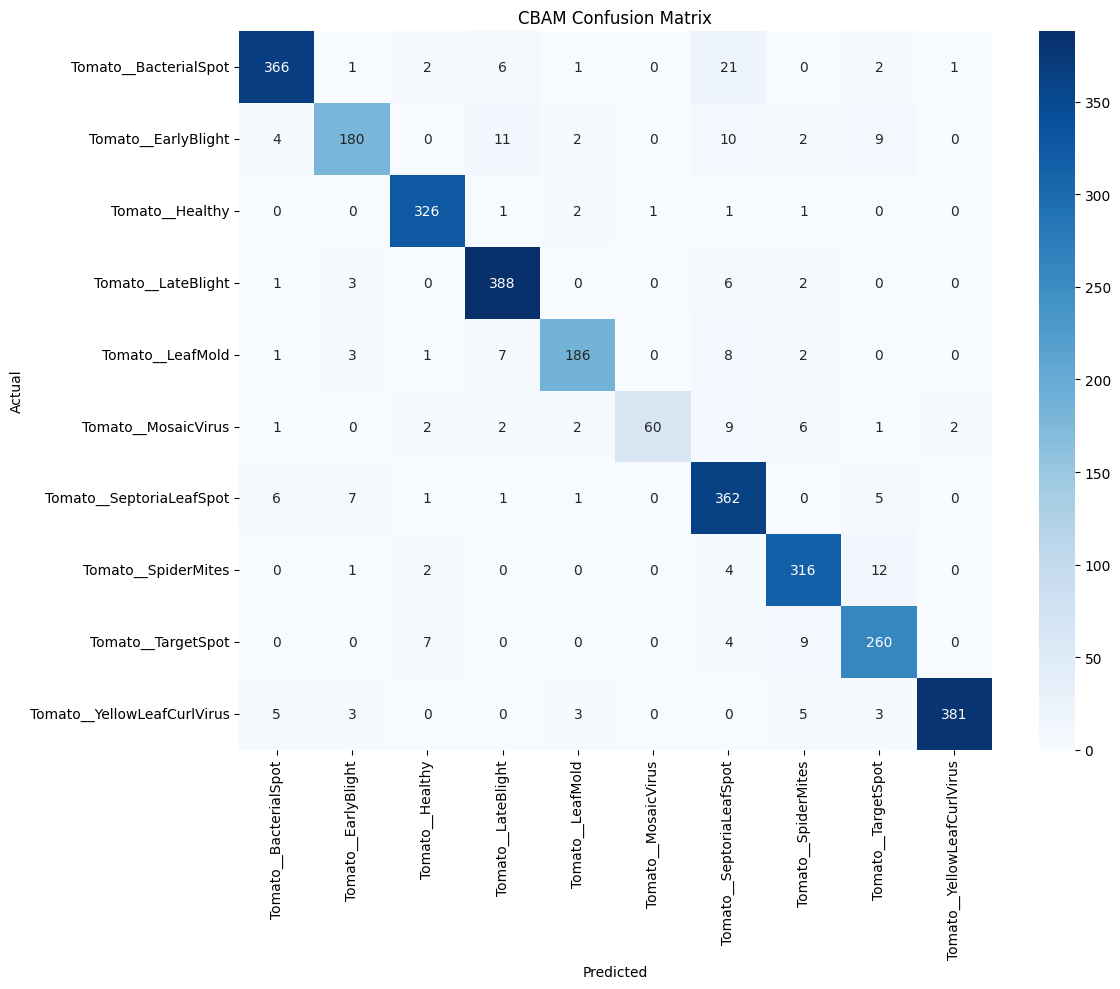

In [22]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_cbam = confusion_matrix(
    y_true,
    cbam_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm_cbam,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "CBAM Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/cbam_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
from sklearn.metrics import classification_report
import pandas as pd

report_cbam = classification_report(
    y_true,
    cbam_pred,
    target_names=class_names,
    output_dict=True
)

pd.DataFrame(
    report_cbam
).transpose().to_csv(
    "/kaggle/working/cbam_classification_report.csv"
)

print("CBAM Report Saved")

CBAM Report Saved


In [25]:
cbam_model.save(
    "/kaggle/working/cbam_model.keras"
)

print("CBAM Model Saved")

CBAM Model Saved


In [26]:
cbam_results = {
    "Model": "MobileNetV3 + CBAM",
    "Accuracy": 0.9290,
    "Macro_F1": 0.92,
    "Weighted_F1": 0.93
}

print(cbam_results)

{'Model': 'MobileNetV3 + CBAM', 'Accuracy': 0.929, 'Macro_F1': 0.92, 'Weighted_F1': 0.93}


In [28]:
comparison_results = [
    {"Model":"MobileNetV3","Accuracy":0.8938,"Macro_F1":0.88,"Weighted_F1":0.89},
    {"Model":"MobileNetV3 + SA","Accuracy":0.8961,"Macro_F1":0.88,"Weighted_F1":0.90},
    {"Model":"MobileNetV3 + CA","Accuracy":0.9234,"Macro_F1":0.91,"Weighted_F1":0.92},
    {"Model":"MobileNetV3 + CBAM","Accuracy":0.9290,"Macro_F1":0.92,"Weighted_F1":0.93}
]

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Model,Accuracy,Macro_F1,Weighted_F1
0,MobileNetV3,0.8938,0.88,0.89
1,MobileNetV3 + SA,0.8961,0.88,0.90
2,MobileNetV3 + CA,0.9234,0.91,0.92
3,MobileNetV3 + CBAM,0.9290,0.92,0.93


In [29]:
cbam_model.save(
    "/kaggle/working/cbam_model.keras"
)

In [30]:
import os

print(
    os.path.exists(
        "/kaggle/working/cbam_model.keras"
    )
)

True


In [31]:
print("base_model_cbam" in globals())

True


HECA CELL 1 — Fresh Backbone

In [32]:
base_model_heca = MobileNetV3Large(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

HECA CELL 2 — Selective Fine-Tuning
(As Mentioned in Paper)

In [33]:
for layer in base_model_heca.layers[:-30]:
    layer.trainable = False

for layer in base_model_heca.layers[-30:]:
    layer.trainable = True

print("HECA Fine-Tuning Ready")

HECA Fine-Tuning Ready


In [36]:
#Build Model
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model_heca(
    x,
    training=True
)

x = cbam_block(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

heca_model = tf.keras.Model(
    inputs,
    outputs
)

heca_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MobileNetV3Large    │ (None, 7, 7, 960) │  2,996,352 │ sequential[2][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ MobileNetV3Large… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 120)       │    115,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 960)       │    116,160 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1, 960) │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_20         │ (None, 7, 7, 960) │          0 │ MobileNetV3Large… │
│ (Multiply)          │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_20[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 7, 7, 1)   │          0 │ multiply_20[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 7, 7, 2)   │          0 │ lambda_4[0][0],   │
│ (Concatenate)       │                   │            │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 1)   │         99 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_21         │ (None, 7, 7, 960) │          0 │ multiply_20[0][0… │
│ (Multiply)          │                   │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 960)       │          0 │ multiply_21[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 960)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10)        │      9,610 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,237,541 (12.35 MB)

 Trainable params: 1,835,909 (7.00 MB)

 Non-trainable params: 1,401,632 (5.35 MB)

In [37]:
#parameter check
print(
    "Trainable:",
    np.sum(
        [np.prod(v.shape)
         for v in heca_model.trainable_weights]
    )
)

print(
    "Non Trainable:",
    np.sum(
        [np.prod(v.shape)
         for v in heca_model.non_trainable_weights]
    )
)

Trainable: 1835909
Non Trainable: 1401632


In [38]:
#compile
heca_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
#callbacks
heca_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_heca_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

heca_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

heca_logger = tf.keras.callbacks.CSVLogger(
    "/kaggle/working/heca_training_log.csv"
)

In [40]:
heca_history = heca_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        heca_checkpoint,
        heca_early_stop,
        heca_logger
    ]
)

Epoch 1/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5260 - loss: 1.4599
Epoch 1: val_accuracy improved from None to 0.73824, saving model to /kaggle/working/best_heca_model.keras

Epoch 1: finished saving model to /kaggle/working/best_heca_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 723s 2s/step - accuracy: 0.7083 - loss: 0.9182 - val_accuracy: 0.7382 - val_loss: 0.7558
Epoch 2/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8851 - loss: 0.3388
Epoch 2: val_accuracy improved from 0.73824 to 0.88030, saving model to /kaggle/working/best_heca_model.keras

Epoch 2: finished saving model to /kaggle/working/best_heca_model.keras
381/381 ━━━━━━━━━━━━━━━━━━━━ 728s 2s/step - accuracy: 0.8968 - loss: 0.3008 - val_accuracy: 0.8803 - val_loss: 0.3585
Epoch 3/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9196 - loss: 0.2348
Epoch 3: val_accuracy improved from 0.88030 to 0.91187, saving model to /kaggle/working/best_heca_model.keras

Epoch 3: finished saving model to /

In [42]:
print(
    "Best Train Accuracy:",
    max(heca_history.history["accuracy"])
)

print(
    "Best Validation Accuracy:",
    max(heca_history.history["val_accuracy"])
)

Best Train Accuracy: 0.9918639063835144
Best Validation Accuracy: 0.9595527648925781
